In [0]:
#----------------------------------------------------------------------------------------------------------------------------------
#
#  Code: CCAR_risk_scoring_Main_Databricks_for_multi_agents.ipynb
#
#  Goal:  This POC is to convert Jingru Chen's Agentic AI Framework for Risk Scoring, Model Governance, and Monitoring to Databricks
#
#  Owner:   Jingru Chen
#  Date:    2026-08-30
#
#-----------------------------------------------------------------------------------------------------------------------------------

### Step 0: Process Flow

In [0]:
# Here is the process flow of Muti-Agent Orchestration for CCAR Risk Scoring 
#
# ccar_core.py
#      │
#      │ provide Classes
#      ↓
# ccar_agents.py
#      │
#      │ provide 12 Agent functions
#      ↓
# ccar_graph.py
#      │
#      │ conect all 12 Agents and create LangGraph
#      ↓
# Main Notebook
#      │
#      │ initial_state
#      │ app.invoke(...)
#      ↓
# End of entire process flow

In [0]:
import importlib
import ccar_config
import ccar_core
import ccar_agents
import ccar_graph

importlib.reload(ccar_config)
importlib.reload(ccar_core)
importlib.reload(ccar_agents)
importlib.reload(ccar_graph)

print("MODULE RELOAD: PASS")

from ccar_graph import build_ccar_graph, display_workflow_result

MODULE RELOAD: PASS


In [0]:
import uuid
import logging
import sys
from datetime import datetime
from zoneinfo import ZoneInfo

RUN_ID = str(uuid.uuid4())
print("\n-------------------- RUN_ID -----------------:", RUN_ID)

start = datetime.now( ZoneInfo("America/New_York"))
print( start.strftime("%Y-%m-%d %H:%M:%S %Z"))     # 2026-03-17 17:34:58 EDT

logger = logging.getLogger("CCAR_RISK_SCORING")
logger.setLevel(logging.INFO)

# Prevent repeated handlers
logger.handlers.clear()

# ============================================================
# 1. Screen Handler
# ============================================================

# screen_handler = logging.StreamHandler(sys.stdout)
# screen_handler.setFormatter(
#     logging.Formatter("%(message)s")
# )

# logger.addHandler(screen_handler)


# ============================================================
# 2. File Handler
# ============================================================

# LOG_FILE = "/Volumes/workspace/risk_scoring/risk_scoring_poc/ccar_engineering_run.txt"

LOG_FILE = "/tmp/ccar_engineering_run.txt"

file_handler = logging.FileHandler(
    LOG_FILE,
    mode="w",
    encoding="utf-8"
)

file_handler.setFormatter(
    logging.Formatter("%(message)s")
)

logger.addHandler(file_handler)

logger.info("LOGGER SETUP : PASS")


-------------------- RUN_ID -----------------: 39172068-0034-49b9-aeb7-99e94bbc82cc
2026-08-30 21:57:06 EDT


### Step 01: Import Python packages

In [0]:
# %pip install sentence-transformers
# %pip install langchain-openai langgraph langsmith pandas pymupdf
# %pip install python-dotenv

%pip install statsmodels sentence-transformers python-dotenv langgraph langchain-openai langsmith openai pandas pymupdf

In [0]:
import os
import pandas as pd
import json
from typing import List
import fitz
import re
import numpy as np
import glob
import matplotlib.pyplot as plt
import json

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

import sqlite3

# Create an in-memory database for our CCAR simulated data
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

from scipy.stats import ks_2samp

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pydantic import BaseModel, Field

from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, END

from openai import OpenAI
from langchain_openai import ChatOpenAI
from langsmith import Client
from langsmith import traceable
from langsmith.utils import LangSmithConflictError
from IPython.display import Image, display

pd.set_option("display.max_colwidth", None)   # Show full text
pd.set_option("display.max_columns", None)    # Show all columns
pd.set_option("display.width", None)          # Unlimited display width
pd.set_option("display.expand_frame_repr", False)


#### Step 01-B: Upload API_KEYs for various LLM and LangSmith

In [0]:
# from dotenv import load_dotenv
# load_dotenv("/content/drive/MyDrive/Colab Notebooks/sample_data/.env")

# =========================
# OPENAI KEY
# =========================

# OPENAI_API_KEY = dbutils.secrets.get(
#     scope="_01_risk-scoring-poc",
#     key="OPENAI_API_KEY"
# )

OPENAI_API_KEY = dbutils.secrets.get(
    scope=ccar_config.SECRET_SCOPE,
    key=ccar_config.OPENAI_SECRET_KEY
)

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY 

openai_client = OpenAI(api_key=OPENAI_API_KEY)
openai_client

# =========================
# LANGSMITH CONFIG
# =========================

# LANGSMITH_API_KEY = dbutils.secrets.get(
#     scope="_01_risk-scoring-poc",
#     key="LANGSMITH_API_KEY"
# )

LANGSMITH_API_KEY = dbutils.secrets.get(
    scope=ccar_config.SECRET_SCOPE,
    key=ccar_config.LANGSMITH_SECRET_KEY
)

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_API_KEY"] = LANGSMITH_API_KEY

# IMPORTANT: correct project name
# os.environ["LANGSMITH_PROJECT"] = "JCHEN-Databricks-credit-risk_scoring-validation-langgraph"
os.environ["LANGSMITH_PROJECT"] = ccar_config.LANGSMITH_PROJECT

# =========================
# 3. Initialize the client
# =========================
client = Client()

print("LangSmith Client: PASS")
print(type(client))

# =========================
# 4. Ensure the project exists
# =========================
# project_name = "JCHEN-Databricks-credit-risck_scoring-validation-langgraph"
project_name = ccar_config.LANGSMITH_PROJECT

try:
    client.create_project(
        project_name=project_name,
        description="Credit Risk Scoring + Validation pipeline"
    )
    print(f"------01-B-01: Successfully created project: {project_name}")

except LangSmithConflictError:
    print(f"------01-B-02: Project '{project_name}' already exists. Proceeding with existing project.")

print(" " * 60)
print("=" * 60)
print("SECURE API CONFIGURATION")
print("=" * 60)
print("OpenAI Secret       : LOADED")
print("LangSmith Secret    : LOADED")
print("LangSmith Tracing   : ENABLED")
print(f"LangSmith Project   : {ccar_config.LANGSMITH_PROJECT}")
print("Status              : PASS")

LangSmith Client: PASS
<class 'langsmith.client.Client'>
------01-B-02: Project 'JCHEN-Databricks-credit-risk_scoring-validation-langgraph' already exists. Proceeding with existing project.
                                                            
SECURE API CONFIGURATION
OpenAI Secret       : LOADED
LangSmith Secret    : LOADED
LangSmith Tracing   : ENABLED
LangSmith Project   : JCHEN-Databricks-credit-risk_scoring-validation-langgraph
Status              : PASS


In [0]:
app = ccar_graph.build_ccar_graph()

print("GRAPH REBUILD: PASS")
print(type(app))

GRAPH REBUILD: PASS
<class 'langgraph.graph.state.CompiledStateGraph'>


### Step 01: Upload risk-scoring Pyspark file

In [0]:
spark_df = spark.table(   "workspace.risk_scoring.mortgage_model_dev" )

print("=" * 60)
print("DATABRICKS DATA LOAD")
print("=" * 60)
print(f"Source Table : workspace.risk_scoring.mortgage_model_dev")
print(f"Rows         : {spark_df.count():,}")
print(f"Columns      : {len(spark_df.columns)}")
print(f"Spark Type   : {type(spark_df).__name__}")
# spark_df.limit(5).show()

display(
    spark_df.select("loan_id", "report_yrmo", "original_balance", "current_balance_bk", "credit_score_orig", "flag_default",
                    "delta_Unemployment1", "hpi_change", "bbb_spread" )\
        .show(5, truncate=False)
)

print("Status       : PASS")

DATABRICKS DATA LOAD
Source Table : workspace.risk_scoring.mortgage_model_dev
Rows         : 67,957
Columns      : 45
Spark Type   : DataFrame
+-------+-----------+----------------+------------------+-----------------+------------+-------------------+-------------------+------------------+
|loan_id|report_yrmo|original_balance|current_balance_bk|credit_score_orig|flag_default|delta_Unemployment1|hpi_change         |bbb_spread        |
+-------+-----------+----------------+------------------+-----------------+------------+-------------------+-------------------+------------------+
|1      |201401     |541879.93       |430203.61         |731.0            |0           |-0.012514          |0.0170338484370801 |1.2373891014962497|
|1      |201402     |541879.93       |430203.61         |731.0            |0           |-0.020281          |0.3405860452529859 |1.5490045758721895|
|1      |201403     |541879.93       |430203.61         |731.0            |0           |-0.030306          |0.4442760

None

Status       : PASS


In [0]:
pd_input_df =  spark_df.toPandas()

print("=" * 60)
print("SPARK → PANDAS DATA INTERFACE")
print("=" * 60)
print(f"{'Spark DataFrame':<22}: READY")
print(f"{'Pandas DataFrame':<22}: READY")
print(f"{'Rows':<22}: {len(pd_input_df):,}")
print(f"{'Columns':<22}: {len(pd_input_df.columns)}")
print(f"{'Status':<22}: PASS")

SPARK → PANDAS DATA INTERFACE
Spark DataFrame       : READY
Pandas DataFrame      : READY
Rows                  : 67,957
Columns               : 45
Status                : PASS


In [0]:
# 5. Here I can invoke the app
initial_state = {
    # Agent 1
    # "input_file": INPUT_FILE_PATH,
    "input_file": pd_input_df,
    "scoring_vintage": "201604",

    # Agent 2 / 3
    "required_columns": ccar_config.x_list_v2,
    "numeric_columns": ccar_config.x_list_v3,
    "target_col": ccar_config.pd_y,

    # Agent 4
    "model_path":   ccar_config.pd_model_path,
    "model_x_list": ccar_config.pd_x_list,
    "pd_threshold": ccar_config.pd_threshold,

    # Agent 8
    "knowledge_base": ccar_config.sample_knowledge_base,

    # Agent 11
    "openai_client": openai_client,
    "llm_model_name": "gpt-4o-mini",
    "semantic_map": ccar_config.semantic_map,
    "sql_conn": conn,
    "sql_user_query": "please let me know the total original balance for HELOC"
}


In [0]:
result = app.invoke(initial_state)

# print("route_result =", result.get("route_result"))
# print("final result keys =", result.keys())

logger.info(
    f"Executive Summary    : "
    f"{'Generated' if result.get('executive_summary') is not None else 'Not Generated'}"
)

logger.info(
    f"Approval Status      : {result.get('approval_status')}"
)

if result.get("executive_summary") is not None:
    logger.info("Full Run Status      : PASS")
else:
    logger.error("Full Run Status      : FAIL")


Input source: Pandas DataFrame
Shape: (67957, 45)
validation_report:


,Validation,Status,Details
0,Required columns,PASS,11 required columns found
1,Duplicate Rows,PASS,No duplicates
2,Missing values,WARNING,"default_date: 53.1%, default_yrmo: 53.1%"
3,YRMO distribution,PASS,49 unique months
4,Target distribution,PASS,Bad rate = 2.50%
5,Outliers,WARNING,5227 values outside 1%-99% range


scoring_report:


,Vintage,Status,Count,Avg_PD,Precision,Recall,F1,TP,FN,TN,FP
0,201604,Success,1179,0.332076,0.033058,0.181818,0.055944,4,18,1040,117


performance_report:


,Metric,Status,Value,Details
0,AUC,WARNING,0.6388,
1,KS,PASS,0.2517,
2,Precision,INFO,0.0331,
3,Recall,INFO,0.1818,
4,F1,INFO,0.0559,
5,Actual Bad Rate,INFO,0.0187,
6,Predicted Bad Rate,INFO,0.1026,
7,Average PD,INFO,0.3321,



LLM TOKEN & COST SUMMARY
Model                 : gpt-4o-mini
Prompt Tokens         : 141
Completion Tokens     : 28
Total Tokens          : 169
------------------------------------------------------------
Input Cost            : $0.00002115
Output Cost           : $0.00001680
Total LLM Cost        : $0.00003795


In [0]:
# print("route_result =", result.get("route_result"))
# print("final result keys =", result.keys())

print("\n" + "=" * 60)
print("FINAL WORKFLOW OUTPUTS")
print("=" * 60)

print(
    f"{'Technical Report':<24}: "
    f"{'Generated' if result.get('technical_report') is not None else 'Not Generated'}"
)

print(
    f"{'RAG Governance':<24}: "
    f"{'Generated' if result.get('rag_answer') is not None else 'Not Generated'}"
)

print(
    f"{'Recommendation':<24}: "
    f"{'Generated' if result.get('recommendation_report') is not None else 'Not Generated'}"
)

print(
    f"{'SQL Analysis':<24}: "
    f"{'Generated' if result.get('sql_result') is not None else 'Not Generated'}"
)

print(
    f"{'Executive Summary':<24}: "
    f"{'Generated' if result.get('executive_summary') is not None else 'Not Generated'}"
)

print("=" * 60)




FINAL WORKFLOW OUTPUTS
Technical Report        : Generated
RAG Governance          : Generated
Recommendation          : Generated
SQL Analysis            : Generated
Executive Summary       : Generated


In [0]:
import shutil

FINAL_LOG_FILE = ( "/Volumes/workspace/risk_scoring/risk_scoring_poc/ccar_engineering_run.txt" )

shutil.copy(
    LOG_FILE,
    FINAL_LOG_FILE
)

print("LOG FILE COPY TO VOLUME: PASS")
print(FINAL_LOG_FILE)

LOG FILE COPY TO VOLUME: PASS
/Volumes/workspace/risk_scoring/risk_scoring_poc/ccar_engineering_run.txt


In [0]:
print("=" * 75)
print("CCAR DATABRICKS FINAL OUTPUT CHECK")
print("=" * 75)

check_keys = [
    "technical_report",
    "_rag_query",
    "_rag_documents",
    "rag_answer",
    "recommendation_report",
    "approval_status",
    "approval_reason",
    "sql_query",
    "sql_result",
    "executive_summary"
]

for k in check_keys:
    value = result.get(k)

    if value is None:
        status = "FAIL - None"
    elif isinstance(value, str) and len(value.strip()) == 0:
        status = "FAIL - Empty"
    else:
        status = "PASS"

    print(f"{k:25s} : {status}")

print("=" * 75)

CCAR DATABRICKS FINAL OUTPUT CHECK
technical_report          : PASS
_rag_query                : PASS
_rag_documents            : PASS
rag_answer                : PASS
recommendation_report     : PASS
approval_status           : PASS
approval_reason           : PASS
sql_query                 : PASS
sql_result                : PASS
executive_summary         : PASS


In [0]:
print("\n===== AGENT 9: RECOMMENDATION =====")
print(result.get("recommendation_report"))

print("\n===== AGENT 10: HUMAN APPROVAL =====")
print("Status:", result.get("approval_status"))
print("Reason:", result.get("approval_reason"))

print("\n===== AGENT 11: DETERMINISTIC SQL =====")
print("SQL:", result.get("sql_query"))
print("Result:", result.get("sql_result"))

print("\n===== AGENT 12: EXECUTIVE SUMMARY =====")
print(result.get("executive_summary"))


===== AGENT 9: RECOMMENDATION =====
  Issue   Status   Value Severity                                                                                      Recommendation Human Approval Required
0   AUC  WARNING  0.6388   MEDIUM  Continue with caution. Review score distribution, PSI, feature drift, and recent vintage behavior.                     Yes

===== AGENT 10: HUMAN APPROVAL =====
Status: PENDING_HUMAN_APPROVAL
Reason: Human approval is required before final reporting.

===== AGENT 11: DETERMINISTIC SQL =====
SQL: 
        SELECT
            report_yrmo,
            SUM(original_balance) AS metric_value
        FROM data_1_uploaded_db
        WHERE product_type = 'HELOC'
          AND date(substr(report_yrmo, 1, 4) || '-' || substr(report_yrmo, 5, 2) || '-01')
              BETWEEN date(substr('201604', 1, 4) || '-' || substr('201604', 5, 2) || '-01', '-5 months')
                  AND date(substr('201604', 1, 4) || '-' || substr('201604', 5, 2) || '-01')
        GROUP BY report

In [0]:
# TEST 9A — Empty DataFrame Test。

# Do not change initial_state。Create a copy of initial_state：

test_state_9A = initial_state.copy()

test_state_9A["input_file"] = pd.DataFrame()

try:
    test_result_9A = app.invoke(test_state_9A)

except Exception as e:
    print("=" * 60)
    print("FAILURE-PATH TEST 9A - EMPTY DATAFRAME")
    print("=" * 60)
    print(f"{'Expected Result':<20}: Pipeline stops")
    print(f"{'Error Type':<20}: {type(e).__name__}")
    print(f"{'Error Message':<20}: {str(e)}")
    print(f"{'Test Status':<20}: PASS")
    print("=" * 60)

FAILURE-PATH TEST 9A - EMPTY DATAFRAME
Expected Result     : Pipeline stops
Error Type          : ValueError
Error Message       : Input DataFrame is empty.
Test Status         : PASS


In [0]:
# TEST 9B — Missing Required Column Test。
# It is to intentionally drop one require column for model scoring

test_state_9B = initial_state.copy()
test_df_9B = pd_input_df.copy()

# Find a required column that is NOT used by Agent 1 numerical summary
candidate_cols = [
    col for col in ccar_config.x_list_v2
    if col not in ccar_config.x_list_v3
]

missing_col = candidate_cols[0]

print("Column intentionally removed:", missing_col)

test_df_9B = test_df_9B.drop(columns=[missing_col])

test_state_9B["input_file"] = test_df_9B

try:
    test_result_9B = app.invoke(test_state_9B)

    print("TEST STATUS : FAIL")
    print("Reason      : Pipeline should have stopped, but it continued.")

except Exception as e:

    print("=" * 60)
    print("FAILURE-PATH TEST 9B - MISSING REQUIRED COLUMN")
    print("=" * 60)
    print(f"{'Removed Column':<20}: {missing_col}")
    print(f"{'Expected Result':<20}: Pipeline stops")
    print(f"{'Error Type':<20}: {type(e).__name__}")
    print(f"{'Error Message':<20}: {str(e)}")
    print(f"{'Test Status':<20}: PASS")
    print("=" * 60)

Column intentionally removed: delta_Unemployment1
Input source: Pandas DataFrame
Shape: (67957, 44)
FAILURE-PATH TEST 9B - MISSING REQUIRED COLUMN
Removed Column      : delta_Unemployment1
Expected Result     : Pipeline stops
Error Type          : Exception
Error Message       : Missing columns: ['delta_Unemployment1']
Test Status         : PASS


In [0]:
# TEST 9C — Invalid Scoring Vintage

test_state_9C = initial_state.copy()

test_state_9C["scoring_vintage"] = "209912"

try:
    test_result_9C = app.invoke(test_state_9C)

    print("TEST STATUS : FAIL")
    print("Reason      : Pipeline should have stopped, but it continued.")

except Exception as e:

    print("=" * 60)
    print("FAILURE-PATH TEST 9C - INVALID SCORING VINTAGE")
    print("=" * 60)
    print(f"{'Test Vintage':<20}: 209912")
    print(f"{'Expected Result':<20}: Pipeline stops")
    print(f"{'Error Type':<20}: {type(e).__name__}")
    print(f"{'Error Message':<20}: {str(e)}")
    print(f"{'Test Status':<20}: PASS")
    print("=" * 60)

Input source: Pandas DataFrame
Shape: (67957, 45)
FAILURE-PATH TEST 9C - INVALID SCORING VINTAGE
Test Vintage        : 209912
Expected Result     : Pipeline stops
Error Type          : ValueError
Error Message       : Scoring vintage 209912 not found in input data.
Test Status         : PASS


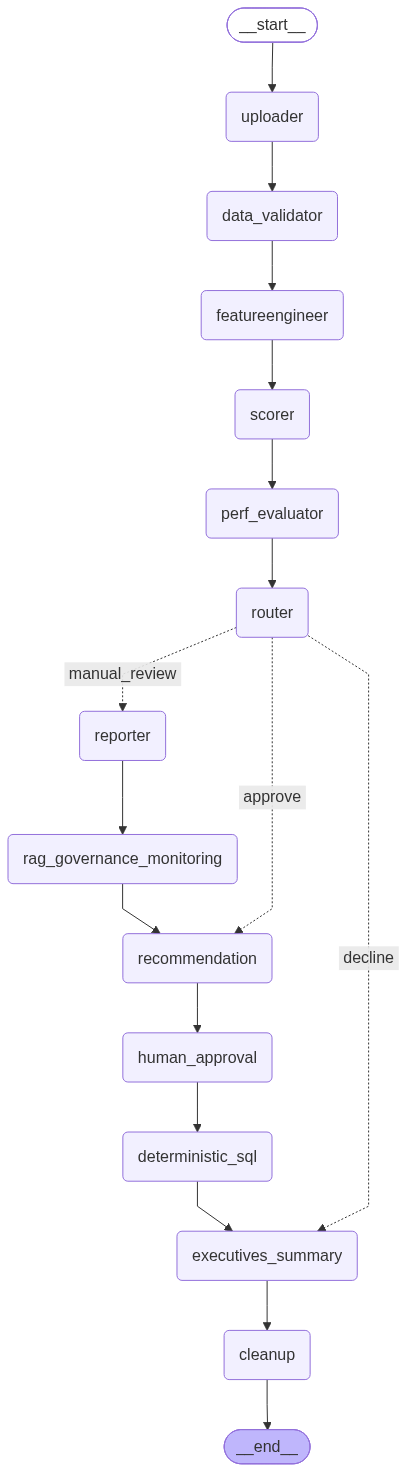

In [0]:
# This generates a PNG of my specific LangGraph workflow structure

display(Image(app.get_graph().draw_mermaid_png()))

------------------------- End of Risk Scoring Multi-Agent Engineering POC -----------